# Stochastic model using Kolmogorov equations

gonna start with a pasture of size A=25

In [255]:
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

In [256]:
N = 43 #number of sheep sheep
R = 0.00888
K = 0.00772
A = 100

In [257]:
#initial state 25 grass blocks
p0 = np.zeros(A+1)
p0[5]=1

In [258]:
#r matrix

def growthRate(Ng):
    return K*Ng*(1-Ng/A)

def eatRate(Ng):
    return N*R*Ng/A

def rij(i, j):
    """value of element r_ij in the r matrix"""

    if i == 0:
        return 0
    elif j == i+1:
        return growthRate(i)
    elif i == j+1:
        return eatRate(i)
    elif i == j:
        return -growthRate(i) - eatRate(i)
    else:
        return 0

In [259]:
r_matrix = np.zeros((A+1,A+1))

for i in range(0, A+1):
    for j in range(0, A+1):
        r_matrix[i,j] = rij(i,j)

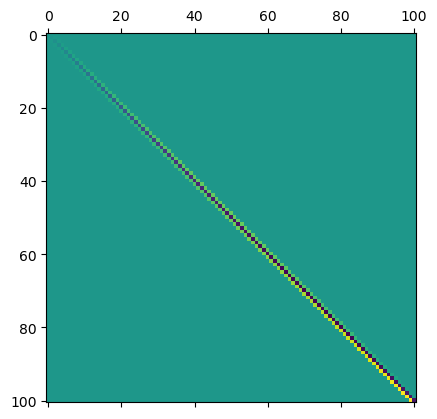

In [260]:
f, ax = plt.subplots()

ax.matshow(r_matrix)

plt.show()

In [261]:
def sys(t, y):
    """"""
    return np.matmul(y, r_matrix)

In [262]:
sys(0, p0)

array([ 0.      ,  0.      ,  0.      ,  0.      ,  0.019092, -0.055762,
        0.03667 ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      , 

In [263]:
sol = sp.integrate.solve_ivp(sys, (0,3600), p0)

In [264]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.416e-02 ...  3.598e+03  3.600e+03]
        y: [[ 0.000e+00  6.682e-21 ...  3.656e-02  3.656e-02]
            [ 0.000e+00  3.621e-16 ...  3.179e-07  3.153e-07]
            ...
            [ 0.000e+00  0.000e+00 ...  7.921e-21  7.870e-21]
            [ 0.000e+00  0.000e+00 ...  1.563e-22  1.571e-22]]
      sol: None
 t_events: None
 y_events: None
     nfev: 6296
     njev: 0
      nlu: 0

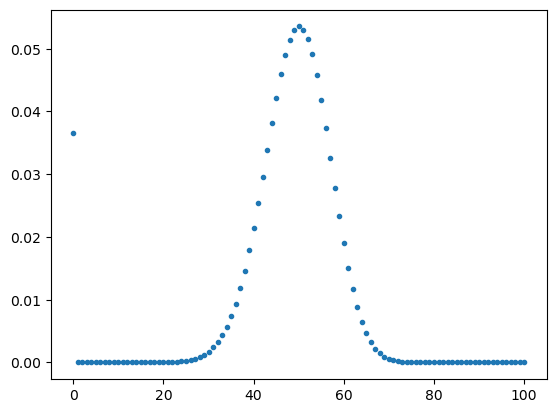

In [269]:
f, ax = plt.subplots()

ax.plot(sol["y"][:,900], ".")

plt.show()

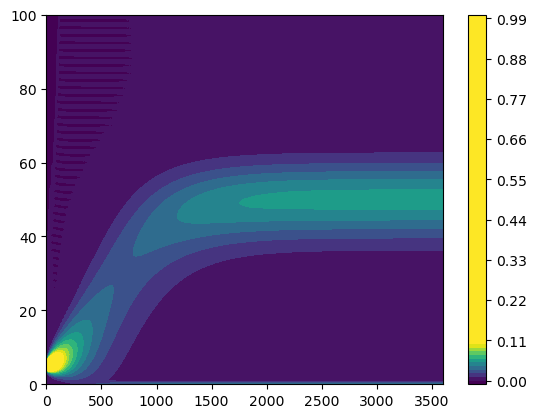

In [266]:
f, ax = plt.subplots()

tt, xx = np.meshgrid(sol["t"], np.arange(0,A+1))

ptr = ax.contourf(tt, xx, sol["y"], vmin=0, vmax=0.1, levels=100)
plt.colorbar(ptr, ax=ax)

plt.show()